In [29]:
import re, warnings, time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from pandas.tseries.offsets import MonthBegin, MonthEnd
from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Parámetros Iniciales y Carga de dataset

In [30]:
CSV_PATH    = '../Data/features_mes_completo.csv'   

TRAIN_START = '2018-01'   # Primer mes del train
TEST_START  = '2025-01'   # Primer mes del test  →  test = un año (2025-01 … 2025-12)

N_CV_FOLDS  = 12          # Folds walk-forward de VALIDACIÓN (un año) para evaluar cada config
N_TRIALS    = 15          # Iteraciones de la búsqueda guiada (warm-start incluido)
SEED        = 42
CI_LEVEL    = 0.90        # Nivel de confianza de los intervalos (MAPE mensual y bandas)

# ── Coste del tuning: se busca la ESTRUCTURA con pocos árboles y se reentrena el
#    modelo final con todos. El nº de árboles apenas cambia el ranking de estructura,
#    así que esto acelera mucho la búsqueda de 12 folds sin perder rigor.
SEARCH_N_ESTIMATORS = 200   # árboles durante la búsqueda (rápido)
FINAL_N_ESTIMATORS  = 400   # árboles del modelo tuneado final (evaluación en test)

ATYPICAL_MONTHS = ['2025-03', '2025-05', '2025-10', '2025-11', '2025-12']
SHOW_ALL_MONTHS_IN_PLOTS = True


RF_BEST_KNOWN = dict(n_estimators=400, max_depth=None, min_samples_leaf=1,
                     max_features=0.5, max_samples=0.8)

# Baseline por defecto (idéntico al del notebook de árboles) para el contraste default vs tuned
DEFAULT_RF = dict(n_estimators=600, max_depth=None, min_samples_leaf=4,
                  max_features='sqrt', max_samples=1.0)
# ─────────────────────────────────────────────────────────────────────────────

def is_atyp(mes):
    return mes in ATYPICAL_MONTHS


In [31]:
df = pd.read_csv(CSV_PATH, index_col='Fecha', parse_dates=True)
df.index = pd.to_datetime(df.index)
df.sort_index(inplace=True)

df = df[df.index >= pd.Timestamp(TRAIN_START + '-01')].copy()


In [32]:
df_sin_rezagos = pd.read_csv('../Data/features_sin_lags_limpio.csv', index_col='Fecha', parse_dates=True)
df_sin_rezagos.index = pd.to_datetime(df_sin_rezagos.index)
df_sin_rezagos.sort_index(inplace=True)

# 2. Función para ajustar a diferentes rezagos y Características del Modelo

In [33]:
def preparar_rf(df, columnas, n_lags):
    data = df[columnas].copy()

    for lag in range(1, n_lags + 1):
        data[f'lag_{lag}'] = df['Consumo'].shift(lag)

    data = data.dropna()

    return data

In [34]:
def get_lag_cols(cols):
    lags = [(int(_pat_lag.match(c).group(1)), c) for c in cols if _pat_lag.match(c)]
    return [c for _, c in sorted(lags)]
    
def features_model(df):
    all_cols = df.columns.tolist()
    _pat_lag = re.compile(r'^lag_(\d+)$')
    
    CALENDAR_ORDINAL = [c for c in [
        'dia_semana','mes', 'semana_año','es_fin_semana','es_festivo',
        'dia_antes_festivo','dia_despues_festivo','semana_navidad',
        'covid_cuarentena','es_mantenimiento'] if c in all_cols]
    
    
    LAG_COLS  = get_lag_cols(all_cols)
    ROLL_COLS = sorted([c for c in all_cols
                        if any(c.startswith(p) for p in
                               ['media_roll','std_roll','mediana_roll'])])
    
     
    return CALENDAR_ORDINAL + LAG_COLS + ROLL_COLS

# 3. Definición dinámica de splits

In [35]:
def preparar_periodos_temporales(
    df,
    test_start,
    n_cv_folds,
    atypical_months=None,
    min_rows_month=20,
    show_all_months_in_plots=False
):
    if atypical_months is None:
        atypical_months = []


    test_start_date = pd.Timestamp(test_start + '-01')

    def month_row_count(period):
        start = period.to_timestamp()
        end = start + MonthEnd(1)

        return len(
            df[
                (df.index >= start) &
                (df.index <= end)
            ]
        )

    # Meses de test
    p = test_start_date.to_period('M')
    last_period = df.index.max().to_period('M')

    test_months = []

    while p <= last_period:
        if month_row_count(p) >= min_rows_month:
            test_months.append(str(p))

        p += 1

    if not test_months:
        raise ValueError(
            f"No hay meses válidos de test desde {test_start}. "
            f"Se requieren al menos {min_rows_month} observaciones por mes."
        )

    # Meses disponibles antes del test
    first_period = df.index.min().to_period('M')

    # Folds CV
    p = (test_start_date - MonthBegin(1)).to_period('M')

    cv_months = []

    while len(cv_months) < n_cv_folds and p >= first_period:

        mes = str(p)

        if (
            month_row_count(p) >= min_rows_month
            and mes not in atypical_months
        ):
            cv_months.insert(0, mes)

        p -= 1

    if len(cv_months) < n_cv_folds:
        raise ValueError(
            f"Solo se encontraron {len(cv_months)} meses válidos para CV, "
            f"pero se solicitaron {n_cv_folds}."
        )

    # Meses estables y atípicos en test
    stable_months = [
        m for m in test_months
        if m not in atypical_months
    ]

    atyp_in_test = [
        m for m in test_months
        if m in atypical_months
    ]

    analysis_months = stable_months

    plot_months = (
        test_months
        if show_all_months_in_plots
        else stable_months
    )

    # Datos anteriores al test
    pre_test = df[df.index < test_start_date].copy()

    return {
        'TEST_MONTHS': test_months,
        'CV_MONTHS': cv_months,
        'STABLE_MONTHS': stable_months,
        'ATYP_IN_TEST': atyp_in_test,
        'ANALYSIS_MONTHS': analysis_months,
        'PLOT_MONTHS': plot_months,
        'pre_test': pre_test,
        'test_start': test_start_date
    }

In [36]:
_pat_lag = re.compile(r'^lag_(\d+)$')

def mask_invalid_lags(X_test: pd.DataFrame) -> pd.DataFrame:
    """Anula lag_k donde k < día del mes (no disponibles en producción)."""
    X_m = X_test.copy()
    
    lag_info = {c: int(_pat_lag.match(c).group(1))
                for c in X_test.columns if _pat_lag.match(c)}
    for date in X_m.index:
        N = date.day
        for col, k in lag_info.items():
            if k < N:
                X_m.loc[date, col] = np.nan
    return X_m


def compute_metrics(y_true, y_pred):
    """Calcula MAE, RMSE, MAPE y R² (idéntico al notebook SARIMAX)."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    r2   = r2_score(y_true, y_pred)
    return {'MAE': round(mae, 2), 'RMSE': round(rmse, 2),
            'MAPE (%)': round(mape, 4), 'R²': round(r2, 4)}


def fit_predict_rf(params, X_train, y_train, X_test_masked):
    """Imputa medias y ajusta RandomForest. Retorna (preds, model) con model._imputer guardado."""
    imp = SimpleImputer(strategy='mean')
    Xtr = imp.fit_transform(X_train)
    Xte = imp.transform(X_test_masked)
    m = RandomForestRegressor(**params, n_jobs=-1, random_state=SEED)
    m.fit(Xtr, y_train)
    m._imputer = imp
    return m.predict(Xte), m


def cv_score_rf(params, cv_months, trial=None):
    """
    Walk-forward CV mensual dentro del train. Para cada mes en cv_months: entrena en todo lo
    anterior y predice ese mes. Retorna dict con MAPE por fold y estadísticos entre folds:
      'mean' (criterio de selección), 'std', 'median', 'folds'.
    Si se pasa `trial` (Optuna), reporta la media acumulada del MAPE fold a fold y habilita el
    PRUNING (corta configuraciones que ya van claramente peor que la mediana, ahorrando folds).
    """
    mapes = []
    for step, mes in enumerate(cv_months):
        cutoff = pd.Timestamp(f'{mes}-01'); end = cutoff + MonthEnd(1)
        tr  = df[df.index < cutoff]
        val = df[(df.index >= cutoff) & (df.index <= end)]
        if len(tr) < 365 or len(val) == 0:
            continue
        Xtr, ytr = tr[FEATURES_TREE], tr['Consumo']
        Xv_m, yv = mask_invalid_lags(val[FEATURES_TREE]), val['Consumo']
        try:
            preds, _ = fit_predict_rf(params, Xtr, ytr, Xv_m)
            mapes.append(compute_metrics(yv.values, preds)['MAPE (%)'])
        except Exception:
            mapes.append(999.0)
        # ── Pruning de Optuna: reporta media acumulada y corta si should_prune() ──
        if trial is not None:
            trial.report(float(np.mean(mapes)), step)
            if trial.should_prune():
                raise optuna.TrialPruned()
    mapes = np.array(mapes, dtype=float)
    if len(mapes) == 0:
        return {'mean': 999.0, 'std': 0.0, 'median': 999.0, 'folds': []}
    return {'mean': float(np.mean(mapes)),
            'std':  float(np.std(mapes, ddof=1)) if len(mapes) > 1 else 0.0,
            'median': float(np.median(mapes)),
            'folds': mapes.tolist()}

# 4. Train/Folds/Test

In [37]:
base_features_lag70 = features_model(df) + ['Consumo']

In [38]:
df_lag70 = df[base_features_lag70].dropna().copy()

In [39]:
periodos = preparar_periodos_temporales(
    df=df_lag70,
    test_start=TEST_START,
    n_cv_folds=N_CV_FOLDS,
    atypical_months=ATYPICAL_MONTHS,
    min_rows_month=20,
    show_all_months_in_plots=SHOW_ALL_MONTHS_IN_PLOTS
)

In [40]:
TEST_MONTHS = periodos['TEST_MONTHS']
CV_MONTHS = periodos['CV_MONTHS']
pre_test = periodos['pre_test']

In [41]:
LAGS_MAX = [7, 14, 21, 30, 40, 50, 60, 70]
TARGET = 'Consumo'

_pat_lag = re.compile(r'^lag_(\d+)$')

# 5. Entrenamiento por Rezago

In [42]:
def definir_train(df, test_start, target='Consumo', max_lag=70):
    test_start = pd.Timestamp(test_start)

    lag_cols = [f'lag_{i}' for i in range(1, max_lag + 1) if f'lag_{i}' in df.columns]

    # Mismas fechas válidas para TODOS los modelos
    df_common = df.dropna(
        subset=[target] + lag_cols
    ).copy()

    train = df_common[df_common.index < test_start].copy()

    return train


def obtener_features(df, max_lag, target='Consumo'):
    base_features = [
        c for c in df.columns
        if c != target and not _pat_lag.match(c)
    ]

    lag_features = [
        f'lag_{i}' for i in range(1, max_lag + 1) if f'lag_{i}' in df.columns
    ]

    return base_features + lag_features

In [43]:
train = definir_train(
    df_lag70,
    test_start=TEST_START
)

In [65]:
def entrenar_rf_por_lags(
    train,
    params,
    max_lags=(7, 14, 21, 30, 60, 70),
    target='Consumo'
):
    resultados = {}
    resultados_train = {}

    for max_lag in max_lags:

        features = obtener_features(
            train,
            max_lag=max_lag,
            target=target
        )

        X_train = train[features]
        y_train = train[target]

        imputer = SimpleImputer(strategy='mean')
        X_train_imp = imputer.fit_transform(X_train)

        model_params = params.copy()
        model_params.setdefault('random_state', 1234)
        model_params.setdefault('n_jobs', -1)

        model = RandomForestRegressor(**model_params)

        model.fit(X_train_imp, y_train)

        pred = model.predict(X_train_imp)

        metricas = compute_metrics(y_train, pred)

        mae = metricas['MAE']
        mape = metricas['MAPE (%)']

        resultados[max_lag] = model

        resultados_train[max_lag] = {
            'MAE': mae,
            'MAPE': mape,
            'MAE_mean': mae,
            'MAPE_mean': mape
        }

    return resultados, resultados_train

In [66]:
modelos, resultados_train = entrenar_rf_por_lags(train, RF_BEST_KNOWN, max_lags=(7, 14, 21, 30, 40, 50, 60, 70))

In [48]:
from sklearn.base import clone
from sklearn.impute import SimpleImputer
from pandas.tseries.offsets import MonthEnd

resultados_cv = {}
for n_lags, modelo in modelos.items():

    mae_folds = []
    mape_folds = []

    features = [
        c for c in df_lag70.columns
        if c != 'Consumo'
        and (
            not _pat_lag.match(c)
            or int(_pat_lag.match(c).group(1)) <= n_lags
        )
    ]

    for mes in CV_MONTHS:

        inicio = pd.Timestamp(f'{mes}-01')
        fin = inicio + MonthEnd(1)

        train_cv = df_lag70[df_lag70.index < inicio]
        val_cv = df_lag70[
            (df_lag70.index >= inicio) &
            (df_lag70.index <= fin)
        ]

        X_train = train_cv[features]
        y_train = train_cv['Consumo']

        X_val = mask_invalid_lags(val_cv[features])
        y_val = val_cv['Consumo']

        imputer = SimpleImputer(strategy='mean')

        X_train = imputer.fit_transform(X_train)
        X_val = imputer.transform(X_val)

        modelo_cv = clone(modelo)
        modelo_cv.fit(X_train, y_train)

        pred = modelo_cv.predict(X_val)

        metricas = compute_metrics(y_val, pred)

        mae_folds.append(metricas['MAE'])
        mape_folds.append(metricas['MAPE (%)'])

    resultados_cv[n_lags] = {
        'MAE': mae_folds,
        'MAPE': mape_folds,
        'MAE_mean': np.mean(mae_folds),
        'MAPE_mean': np.mean(mape_folds)
    }

In [58]:
def evaluar_test_modelos(
    modelos,
    df_lag70,
    TEST_MONTHS,
    ATYPICAL_MONTHS,
    target='Consumo'
):
    resultados_test = {}

    for n_lags, modelo in modelos.items():

        mae_meses = []
        mape_meses = []
        predicciones = []

        features = [
            c for c in df_lag70.columns
            if c != target
            and (
                not _pat_lag.match(c)
                or int(_pat_lag.match(c).group(1)) <= n_lags
            )
        ]

        for mes in TEST_MONTHS:
            inicio = pd.Timestamp(f'{mes}-01')
            fin = inicio + MonthEnd(1)

            train_mes = df_lag70[df_lag70.index < inicio]

            test_mes = df_lag70[
                (df_lag70.index >= inicio) &
                (df_lag70.index <= fin)
            ]

            X_train = train_mes[features]
            y_train = train_mes[target]

            X_test = mask_invalid_lags(test_mes[features])
            y_test = test_mes[target]

            imputer = SimpleImputer(strategy='mean')

            X_train = imputer.fit_transform(X_train)
            X_test = imputer.transform(X_test)

            modelo_test = clone(modelo)
            modelo_test.fit(X_train, y_train)

            pred = modelo_test.predict(X_test)

            if mes not in ATYPICAL_MONTHS:
                metricas = compute_metrics(y_test, pred)
                
                mae_meses.append(metricas['MAE'])
                mape_meses.append(metricas['MAPE (%)'])

            predicciones.append(
                pd.DataFrame({
                    'Real': y_test.values,
                    'Prediccion': pred,
                    'Mes': mes
                }, index=y_test.index)
            )

        resultados_test[n_lags] = {
            'MAE': mae_meses,
            'MAPE': mape_meses,
            'MAE_mean': np.mean(mae_meses),
            'MAPE_mean': np.mean(mape_meses),
            'predicciones': pd.concat(predicciones)
        }

    return resultados_test

In [71]:
def analizar_resultados(
    resultados_cv,
    resultados_test,
    resultados_train,
    train,
    target='Consumo'
):


    lags = sorted(resultados_cv.keys())

    # ─────────────────────────────────────────────
    # 1. Tabla comparativa
    # ─────────────────────────────────────────────

    tabla = pd.DataFrame({
        'Lags': lags,

        'Train MAE': [
            resultados_train[k]['MAE_mean']
            for k in lags
        ],

        'Train MAPE (%)': [
            resultados_train[k]['MAPE_mean']
            for k in lags
        ],

        'CV MAE': [
            resultados_cv[k]['MAE_mean']
            for k in lags
        ],

        'CV MAPE (%)': [
            resultados_cv[k]['MAPE_mean']
            for k in lags
        ],

        'Test MAE': [
            resultados_test[k]['MAE_mean']
            for k in lags
        ],

        'Test MAPE (%)': [
            resultados_test[k]['MAPE_mean']
            for k in lags
        ]
    })

    print(tabla.to_string(index=False))


    # ─────────────────────────────────────────────
    # 2. MAE según número de rezagos
    # ─────────────────────────────────────────────

    plt.figure(figsize=(9, 5))


    plt.plot(
        tabla['Lags'],
        tabla['CV MAE'],
        marker='o',
        label='CV'
    )

    plt.plot(
        tabla['Lags'],
        tabla['Test MAE'],
        marker='o',
        label='Test'
    )

    plt.xlabel('Número máximo de rezagos')
    plt.ylabel('MAE')
    plt.title('MAE según cantidad de rezagos')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


    # ─────────────────────────────────────────────
    # 3. MAPE según número de rezagos
    # ─────────────────────────────────────────────

    plt.figure(figsize=(9, 5))


    plt.plot(
        tabla['Lags'],
        tabla['CV MAPE (%)'],
        marker='o',
        label='CV'
    )

    plt.plot(
        tabla['Lags'],
        tabla['Test MAPE (%)'],
        marker='o',
        label='Test'
    )

    plt.xlabel('Número máximo de rezagos')
    plt.ylabel('MAPE (%)')
    plt.title('MAPE según cantidad de rezagos')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


    # ─────────────────────────────────────────────
    # 4. Serie temporal del train
    # ─────────────────────────────────────────────

    plt.figure(figsize=(14, 5))

    plt.plot(
        train.index,
        train[target]
    )

    plt.xlabel('Fecha')
    plt.ylabel(target)
    plt.title('Serie temporal de entrenamiento')
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


    # ─────────────────────────────────────────────
    # 5. MAPE por fold de CV
    # ─────────────────────────────────────────────

    plt.figure(figsize=(10, 5))

    for n_lags in lags:

        plt.plot(
            range(1, len(resultados_cv[n_lags]['MAPE']) + 1),
            resultados_cv[n_lags]['MAPE'],
            marker='o',
            label=f'{n_lags} lags'
        )

    plt.xlabel('Fold')
    plt.ylabel('MAPE (%)')
    plt.title('MAPE por fold de validación cruzada')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


    return tabla

# 6. Análisis de Resultados por Rezagos

## A. Sin incluir atípicos

In [ ]:
resultados_test = evaluar_test_modelos(
    modelos,
    df_lag70,
    TEST_MONTHS,
    ATYPICAL_MONTHS,
    target='Consumo'
)

 Lags  Train MAE  Train MAPE (%)      CV MAE  CV MAPE (%)    Test MAE  Test MAPE (%)
    7    1359.95          2.3197 4300.012500     6.667433 2888.327143       5.660614
   14    1365.85          2.3312 4077.244167     6.315650 2967.437143       5.842000
   21    1389.07          2.3728 4037.096667     6.220833 2911.778571       5.664486
   30    1393.01          2.3784 3981.644167     6.127650 2971.454286       5.782686
   40    1394.37          2.3809 3889.754167     5.946917 2913.201429       5.660729
   50    1417.73          2.4191 3941.798333     6.010708 2913.882857       5.715929
   60    1398.32          2.3818 3790.669167     5.711742 2917.621429       5.653400
   70    1400.27          2.3844 3700.976667     5.617100 2910.554286       5.645871


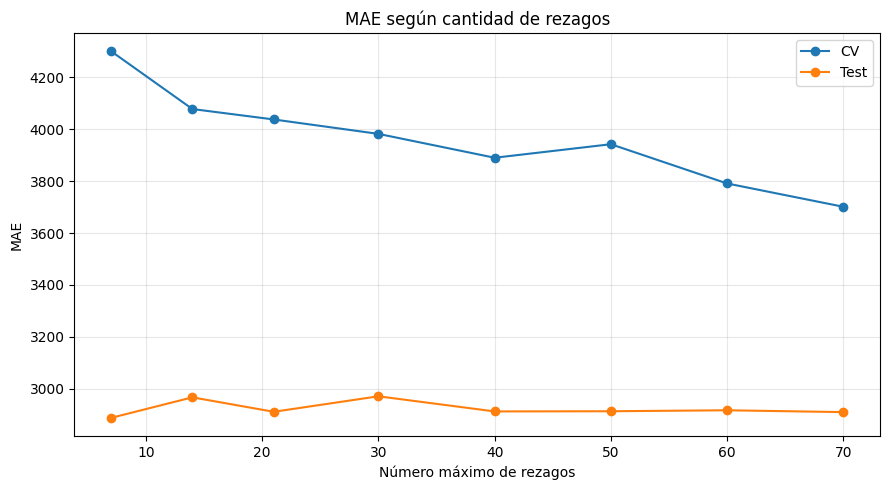

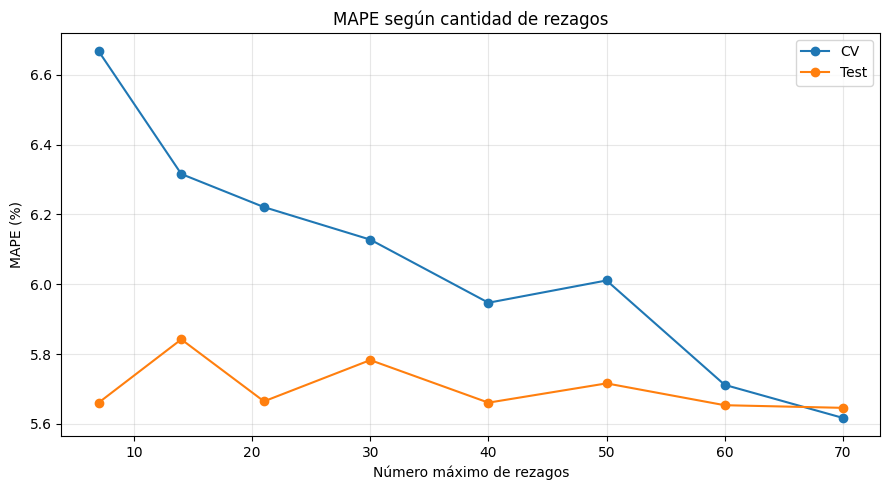

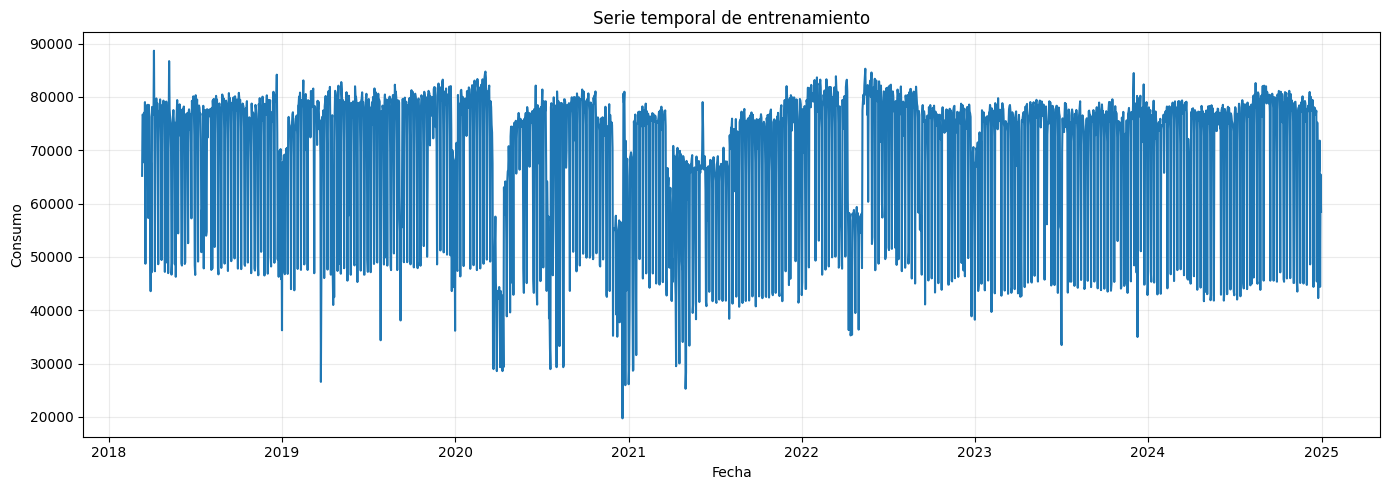

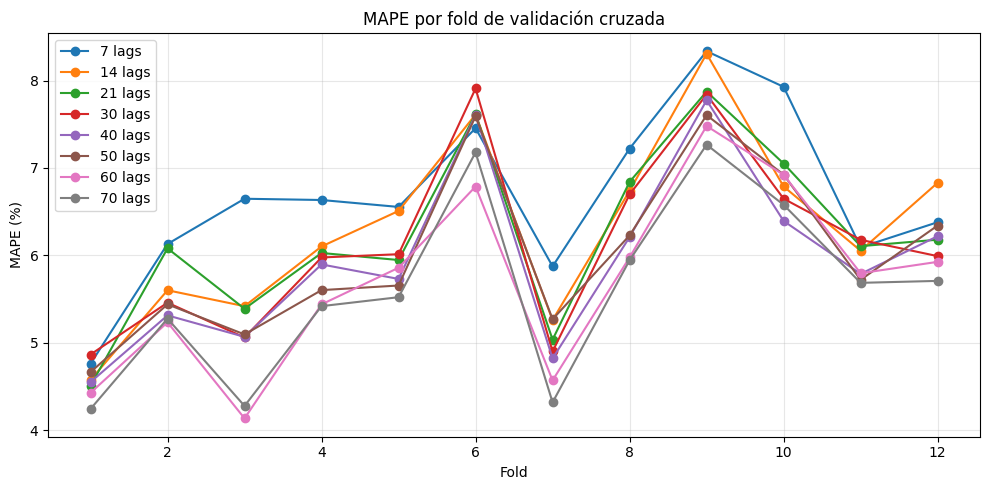

,Lags,Train MAE,Train MAPE (%),CV MAE,CV MAPE (%),Test MAE,Test MAPE (%)
0,7,1359.95,2.3197,4300.012500,6.667433,2888.327143,5.660614
1,14,1365.85,2.3312,4077.244167,6.315650,2967.437143,5.842000
2,21,1389.07,2.3728,4037.096667,6.220833,2911.778571,5.664486
3,30,1393.01,2.3784,3981.644167,6.127650,2971.454286,5.782686
4,40,1394.37,2.3809,3889.754167,5.946917,2913.201429,5.660729
5,50,1417.73,2.4191,3941.798333,6.010708,2913.882857,5.715929
6,60,1398.32,2.3818,3790.669167,5.711742,2917.621429,5.653400
7,70,1400.27,2.3844,3700.976667,5.617100,2910.554286,5.645871


In [72]:
analizar_resultados(resultados_cv, resultados_test, resultados_train, train, target='Consumo')

# B. Incluyendo atípicos

In [69]:
resultados_test_atp = evaluar_test_modelos(
    modelos,
    df_lag70,
    TEST_MONTHS,
    [],
    target='Consumo'
)

 Lags  Train MAE  Train MAPE (%)      CV MAE  CV MAPE (%)    Test MAE  Test MAPE (%)
    7    1359.95          2.3197 4300.012500     6.667433 4095.171667       8.718658
   14    1365.85          2.3312 4077.244167     6.315650 4226.961667       8.987758
   21    1389.07          2.3728 4037.096667     6.220833 4219.140000       8.929242
   30    1393.01          2.3784 3981.644167     6.127650 4180.169167       8.877400
   40    1394.37          2.3809 3889.754167     5.946917 4172.809167       8.822192
   50    1417.73          2.4191 3941.798333     6.010708 4174.926667       8.882692
   60    1398.32          2.3818 3790.669167     5.711742 4191.751667       8.846133
   70    1400.27          2.3844 3700.976667     5.617100 4140.396667       8.765917


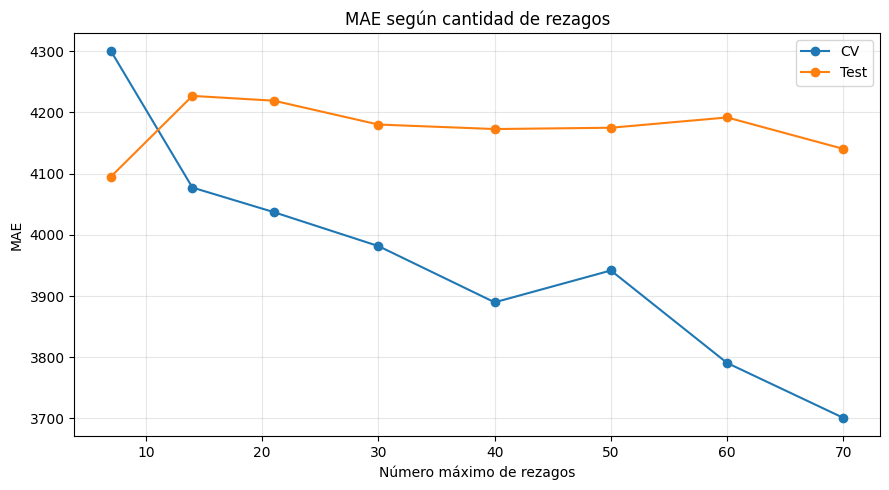

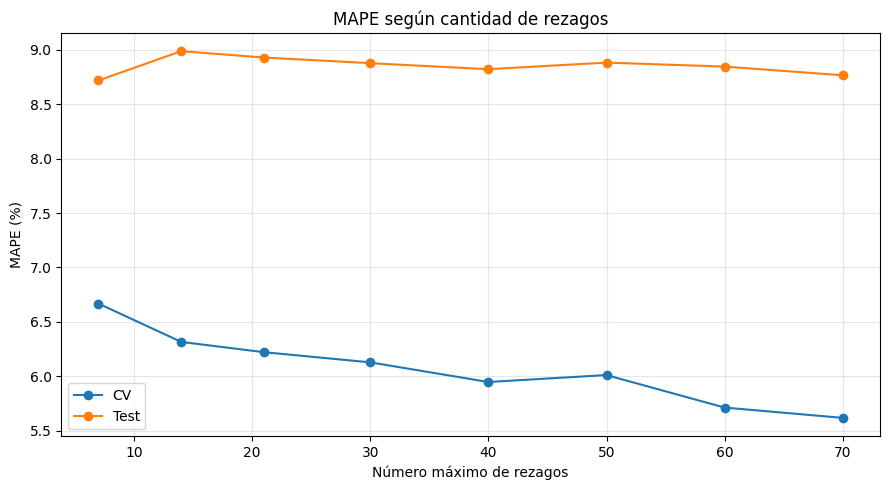

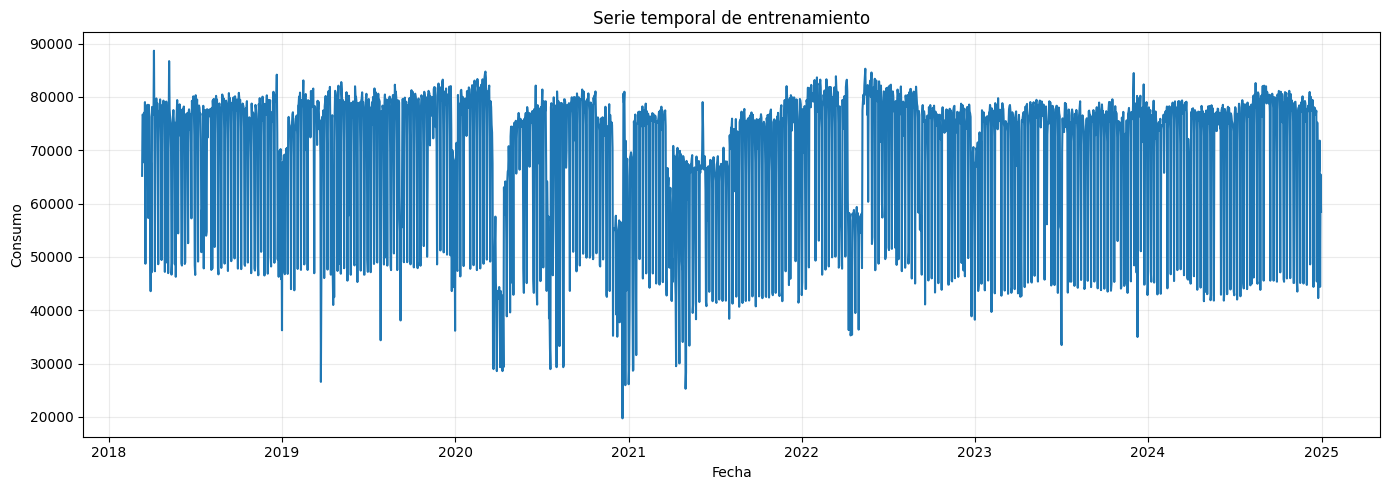

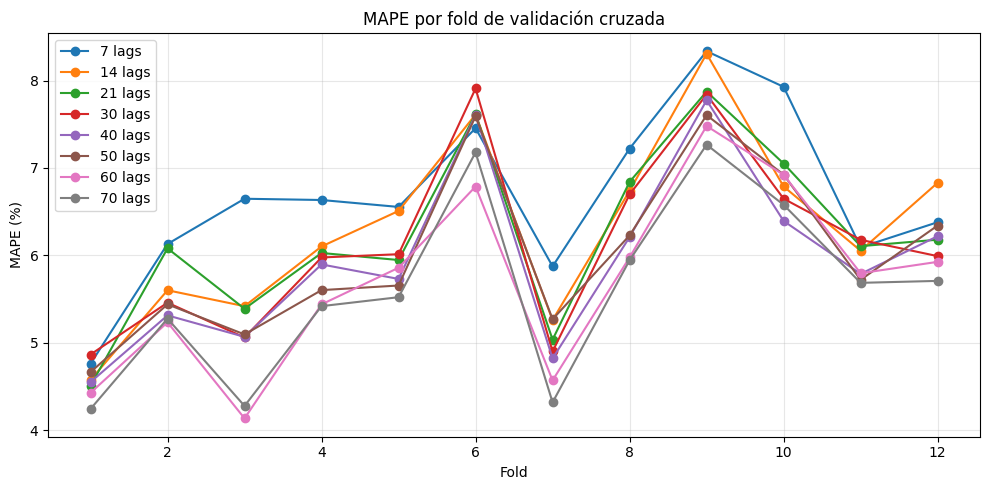

,Lags,Train MAE,Train MAPE (%),CV MAE,CV MAPE (%),Test MAE,Test MAPE (%)
0,7,1359.95,2.3197,4300.012500,6.667433,4095.171667,8.718658
1,14,1365.85,2.3312,4077.244167,6.315650,4226.961667,8.987758
2,21,1389.07,2.3728,4037.096667,6.220833,4219.140000,8.929242
3,30,1393.01,2.3784,3981.644167,6.127650,4180.169167,8.877400
4,40,1394.37,2.3809,3889.754167,5.946917,4172.809167,8.822192
5,50,1417.73,2.4191,3941.798333,6.010708,4174.926667,8.882692
6,60,1398.32,2.3818,3790.669167,5.711742,4191.751667,8.846133
7,70,1400.27,2.3844,3700.976667,5.617100,4140.396667,8.765917


In [73]:
analizar_resultados(resultados_cv, resultados_test_atp, resultados_train, train, target='Consumo')